# 1.libraries

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve
)

# 2. Create Synthetic Corporate Banking Dataset

In [ ]:
np.random.seed(42)

n_clients = 1000

df = pd.DataFrame({
    "Client_Tenure_Months": np.random.randint(1, 120, n_clients),
    "Annual_Revenue_Millions": np.random.uniform(5, 500, n_clients),
    "Recent_Support_Tickets": np.random.randint(0, 20, n_clients),
    "Executive_Meeting_Attendance": np.random.uniform(0, 1, n_clients),
    "API_Usage_Volume": np.random.randint(100, 10000, n_clients)
})

# 3. Create Realistic Purchase Probability

In [ ]:
score = (
    0.00025 * df["API_Usage_Volume"]
    + 2.5 * df["Executive_Meeting_Attendance"]
    + 0.008 * df["Annual_Revenue_Millions"]
    + 0.015 * df["Client_Tenure_Months"]
    - 0.15 * df["Recent_Support_Tickets"]
    - 3
)

purchase_probability = 1 / (1 + np.exp(-score))

df["Propensity_to_Purchase"] = (
    np.random.rand(n_clients) < purchase_probability
).astype(int)

# 4. Dataset Preview

In [ ]:
print("\nDataset Preview")
print(df.head())

print("\nTarget Distribution")
print(df["Propensity_to_Purchase"].value_counts())


Dataset Preview
   Client_Tenure_Months  Annual_Revenue_Millions  Recent_Support_Tickets  \
0                   103               379.714570                       3   
1                    52                28.213752                      19   
2                    93               137.992879                       3   
3                    15                15.981447                       6   
4                   107               251.591767                       0   

   Executive_Meeting_Attendance  API_Usage_Volume  Propensity_to_Purchase  
0                      0.138871              1729                       1  
1                      0.115738              6959                       0  
2                      0.154322              8941                       1  
3                      0.171848              3378                       0  
4                      0.637877              5555                       1  

Target Distribution
Propensity_to_Purchase
1    670
0    330
Name: co

# 5. Feature & Target Split

In [ ]:
X = df.drop("Propensity_to_Purchase", axis=1)
y = df["Propensity_to_Purchase"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# 6. Train Random Forest Model

In [ ]:
rf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=8,
    class_weight="balanced",
    random_state=42
)

rf_model.fit(X_train, y_train)



,n_estimators,300
,criterion,'gini'
,max_depth,8
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


# 7. Predictions

In [ ]:
y_pred = rf_model.predict(X_test)

y_prob = rf_model.predict_proba(X_test)[:, 1]

# 8. Evaluation Metrics

In [19]:
accuracy = accuracy_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob)

print("\n==============================")
print("MODEL PERFORMANCE")
print("==============================")

print(f"Accuracy : {accuracy:.4f}")
print(f"ROC-AUC  : {roc_auc:.4f}")

print("\nClassification Report")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix")
print(confusion_matrix(y_test, y_pred))


MODEL PERFORMANCE
Accuracy : 0.8350
ROC-AUC  : 0.9088

Classification Report
              precision    recall  f1-score   support

           0       0.77      0.71      0.74        66
           1       0.86      0.90      0.88       134

    accuracy                           0.83       200
   macro avg       0.82      0.80      0.81       200
weighted avg       0.83      0.83      0.83       200


Confusion Matrix
[[ 47  19]
 [ 14 120]]


# 9. Cross Validation

In [ ]:
cv_scores = cross_val_score(
    rf_model,
    X,
    y,
    cv=5,
    scoring="roc_auc"
)

print("\n5-Fold Cross Validation ROC-AUC Scores")
print(cv_scores)

print(f"\nAverage ROC-AUC: {cv_scores.mean():.4f}")


5-Fold Cross Validation ROC-AUC Scores
[0.82553143 0.79692447 0.79296698 0.88523293 0.87211669]

Average ROC-AUC: 0.8346


# 10. Feature Importance

In [ ]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

print("\nLeading Indicators of Expansion Readiness")
print(feature_importance)


Leading Indicators of Expansion Readiness
                        Feature  Importance
1       Annual_Revenue_Millions    0.257749
4              API_Usage_Volume    0.193044
3  Executive_Meeting_Attendance    0.191694
2        Recent_Support_Tickets    0.189602
0          Client_Tenure_Months    0.167912


# 11. Plot Feature Importance

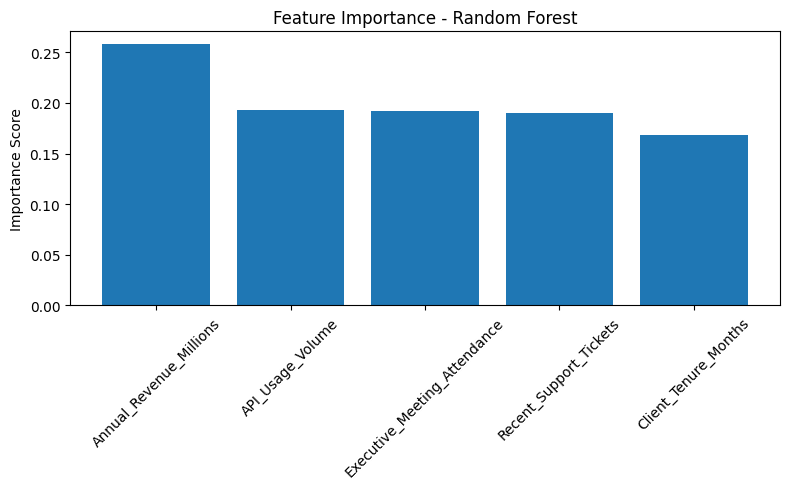

In [ ]:
plt.figure(figsize=(8,5))
plt.bar(
    feature_importance["Feature"],
    feature_importance["Importance"]
)
plt.xticks(rotation=45)
plt.title("Feature Importance - Random Forest")
plt.ylabel("Importance Score")
plt.tight_layout()
plt.show()

# 12. ROC Curve

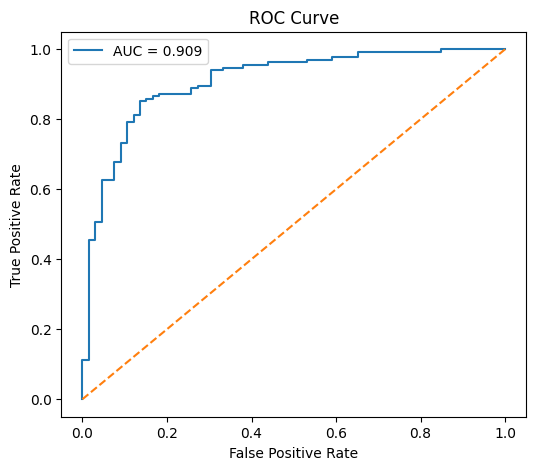

In [ ]:
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0,1], [0,1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

# 13. High-Potential Client List

In [ ]:
client_scores = X_test.copy()

client_scores["Purchase_Probability"] = y_prob

high_potential = client_scores.sort_values(
    by="Purchase_Probability",
    ascending=False
)

print("\nTop 10 Expansion Opportunities")
print(
    high_potential[
        [
            "Client_Tenure_Months",
            "Annual_Revenue_Millions",
            "Executive_Meeting_Attendance",
            "API_Usage_Volume",
            "Purchase_Probability"
        ]
    ].head(10)
)


Top 10 Expansion Opportunities
     Client_Tenure_Months  Annual_Revenue_Millions  \
34                    108               421.835250   
894                    74               470.210797   
496                    25               402.968605   
147                    73               356.921477   
616                   110               440.140383   
238                    27               359.508642   
898                   102               366.760590   
180                    90               362.190293   
366                   116               184.714310   
754                    28               476.017237   

     Executive_Meeting_Attendance  API_Usage_Volume  Purchase_Probability  
34                       0.889652              6818              0.994305  
894                      0.753595              8476              0.993195  
496                      0.992442              9180              0.989280  
147                      0.894453              5313              0.98